# GPVS-Faults EDA
Exploratory data analysis of the GPVS-Faults dataset (Bakdi et al., 2020), focused on the 8 MPPT-mode files used by Li et al. (2025) as the benchmark for Paper 2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "CSV_Files/"

df0 = pd.read_csv(path + "F0M.csv")
df1 = pd.read_csv(path + "F1M.csv")
df2 = pd.read_csv(path + "F2M.csv")
df3 = pd.read_csv(path + "F3M.csv")
df4 = pd.read_csv(path + "F4M.csv")
df5 = pd.read_csv(path + "F5M.csv")
df6 = pd.read_csv(path + "F6M.csv")
df7 = pd.read_csv(path + "F7M.csv")

### Row counts per file

Verify that sample counts match Li et al.'s Table II, confirming MPPT-mode files are being used.

In [2]:
files = {
    'F0M': df0, 'F1M': df1, 'F2M': df2, 'F3M': df3,
    'F4M': df4, 'F5M': df5, 'F6M': df6, 'F7M': df7
}

inventory = pd.DataFrame({
    'file': list(files.keys()),
    'rows': [len(df) for df in files.values()],
    'duration_s': [df['Time'].iloc[-1] - df['Time'].iloc[0] for df in files.values()],
    'nan_count': [df.isna().sum().sum() for df in files.values()]
})
inventory['rows_Li_et_al'] = [141014, 139014, 144015, 69967, 144014, 144014, 144015, 144015]
inventory['match'] = inventory['rows'] == inventory['rows_Li_et_al']
inventory

,file,rows,duration_s,nan_count,rows_Li_et_al,match
0,F0M,141014,14.099888,0,141014,True
1,F1M,139014,13.899897,0,139014,True
2,F2M,144015,14.399960,0,144015,True
3,F3M,69967,6.995897,0,69967,True
4,F4M,144014,14.399866,0,144014,True
5,F5M,144014,14.399863,0,144014,True
6,F6M,144015,14.399917,0,144015,True
7,F7M,144015,14.399846,0,144015,True


### Column structure

14 columns total: `Time` (excluded from modelling) plus 13 electrical measurements grouped as DC side, three-phase AC, and derived AC quantities.

In [3]:
df0.columns.tolist()

['Time',
 'Ipv',
 'Vpv',
 'Vdc',
 'ia',
 'ib',
 'ic',
 'va',
 'vb',
 'vc',
 'Iabc',
 'If',
 'Vabc',
 'Vf']

### Sampling regularity

Confirm the ~9.9989 μs sampling interval documented by Bakdi et al. is consistent across F0M.

In [4]:
dt = df0['Time'].diff().dropna()
print(f"Sampling interval — mean: {dt.mean()*1e6:.4f} μs, "
      f"std: {dt.std()*1e6:.4f} μs, "
      f"min: {dt.min()*1e6:.4f} μs, "
      f"max: {dt.max()*1e6:.4f} μs")

Sampling interval — mean: 99.9900 μs, std: 0.0584 μs, min: 95.0117 μs, max: 104.9820 μs


## Reference Signal

F0M represents fault-free operation. The plots below establish the healthy baseline across all subsystems — the reference pattern against which each fault class will be compared in later fault data.

### Plot 1 — Small-multiples overview by subsystem

The 13 features grouped by scale: DC voltages, three-phase AC voltages, derived AC voltage magnitude, currents, and frequencies. Each subsystem gets its own y-axis so magnitude differences across groups do not obscure within-group behaviour.

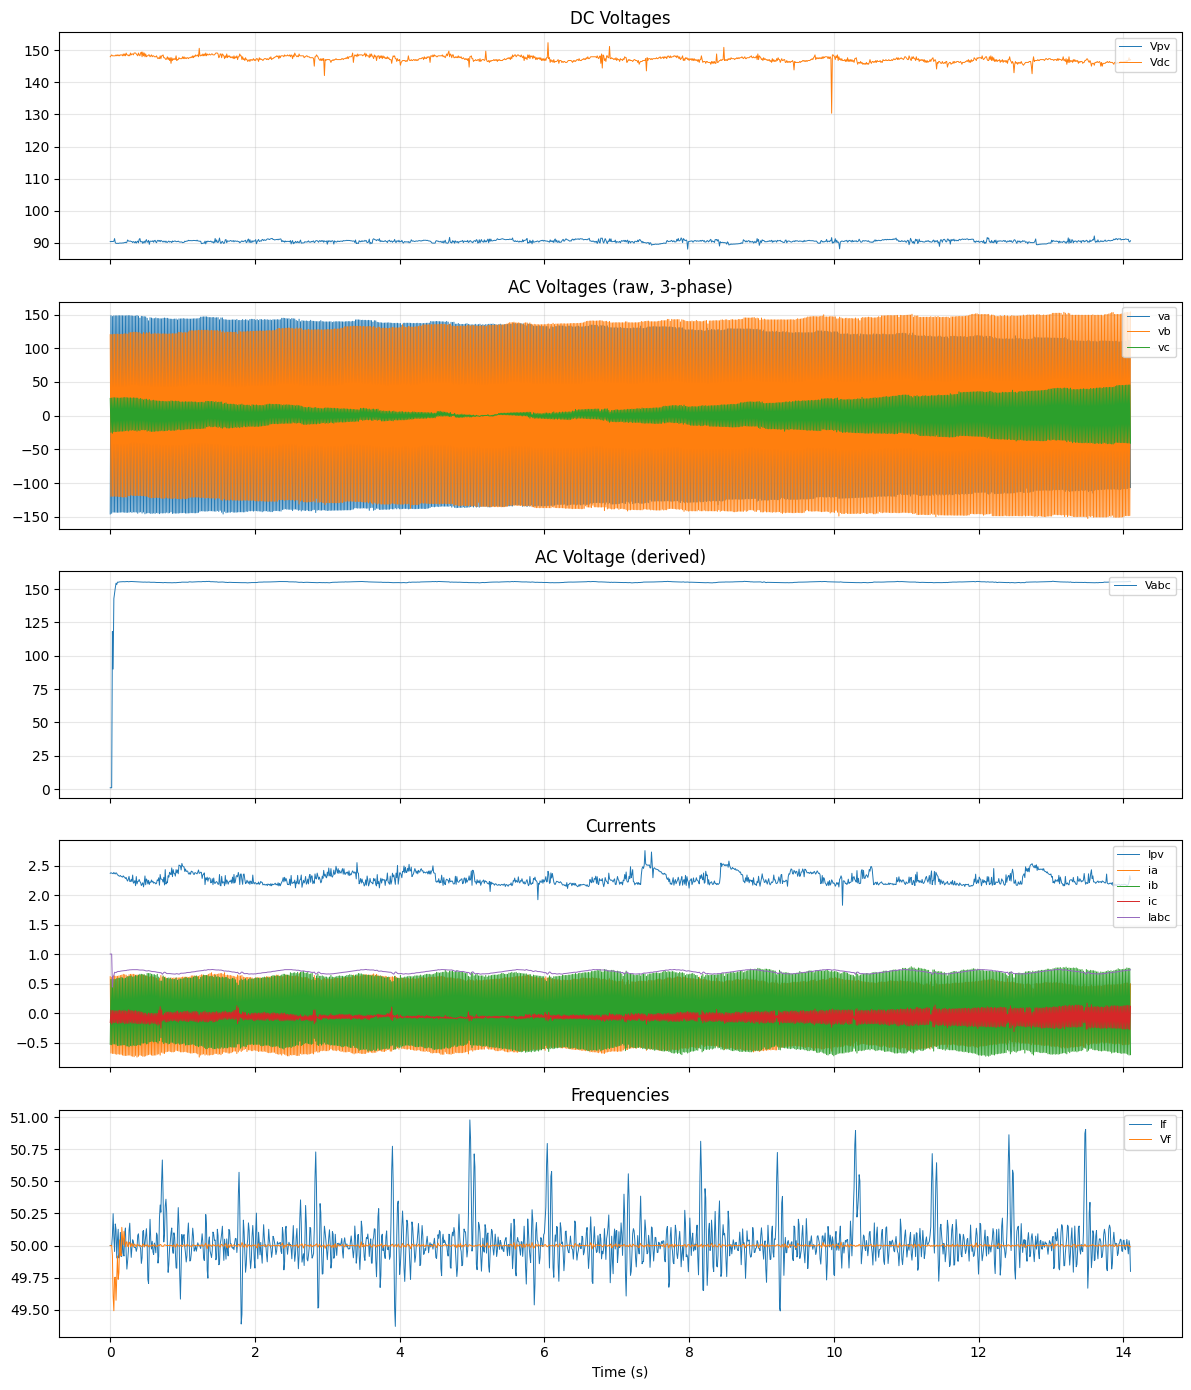

In [5]:
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

groups = {
    'DC Voltages': ['Vpv', 'Vdc'],
    'AC Voltages (raw, 3-phase)': ['va', 'vb', 'vc'],
    'AC Voltage (derived)': ['Vabc'],
    'Currents': ['Ipv', 'ia', 'ib', 'ic', 'Iabc'],
    'Frequencies': ['If', 'Vf']
}

# Downsample for rendering — take every `stride` point
stride = 100
df_viz = df0.iloc[::stride]

for ax, (title, cols) in zip(axes, groups.items()):
    for col in cols:
        ax.plot(df_viz['Time'], df_viz[col], label=col, linewidth=0.7)
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

### Plot 2 — Three-phase AC voltage zoom-in

At full duration, the ~50 Hz AC voltages compress into a solid band because each pixel column spans many cycles. A 100 ms window from the middle of the experiment reveals the expected balanced three-phase sinusoidal structure.

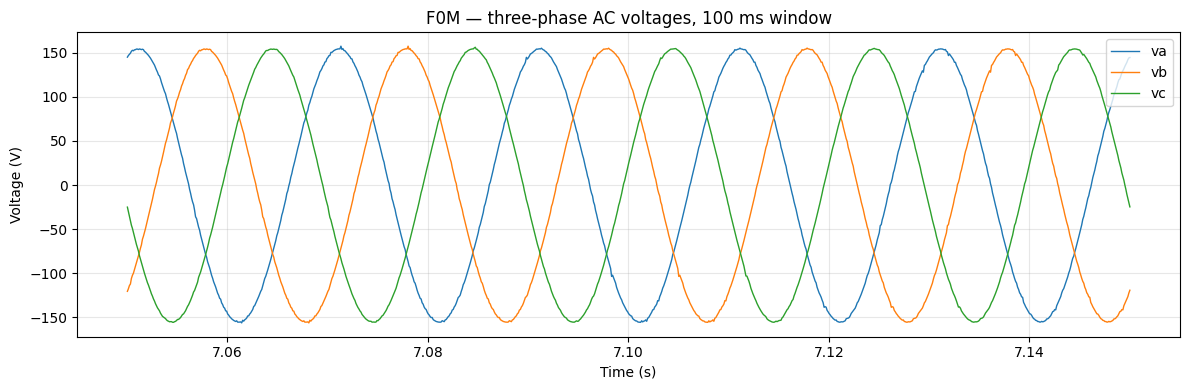

In [6]:
# 100 ms window from the middle of F0M
t_mid = df0['Time'].iloc[len(df0) // 2]
mask = (df0['Time'] >= t_mid) & (df0['Time'] <= t_mid + 0.1)
df_zoom = df0[mask]

fig, ax = plt.subplots(figsize=(12, 4))
for col in ['va', 'vb', 'vc']:
    ax.plot(df_zoom['Time'], df_zoom[col], label=col, linewidth=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')
ax.set_title('F0M — three-phase AC voltages, 100 ms window')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 3 — Feature correlation heatmap

Correlations computed on data subsampled at stride=100 to avoid numerical artefacts from the high-frequency AC oscillations. `Time` is excluded because it is a monotonic index rather than a physical measurement.

Expected physical relationships to look for:
- **Ipv vs Vpv** — negative correlation from the PV I–V curve.
- **Vdc vs Iabc** — positive correlation from DC-link to AC-side power transfer.
- **va/vb/vc pairwise** — near -0.5 for balanced three-phase (120° apart).
- **If and Vf** — weakly correlated with raw signals since they are frequency estimates around 50 Hz.

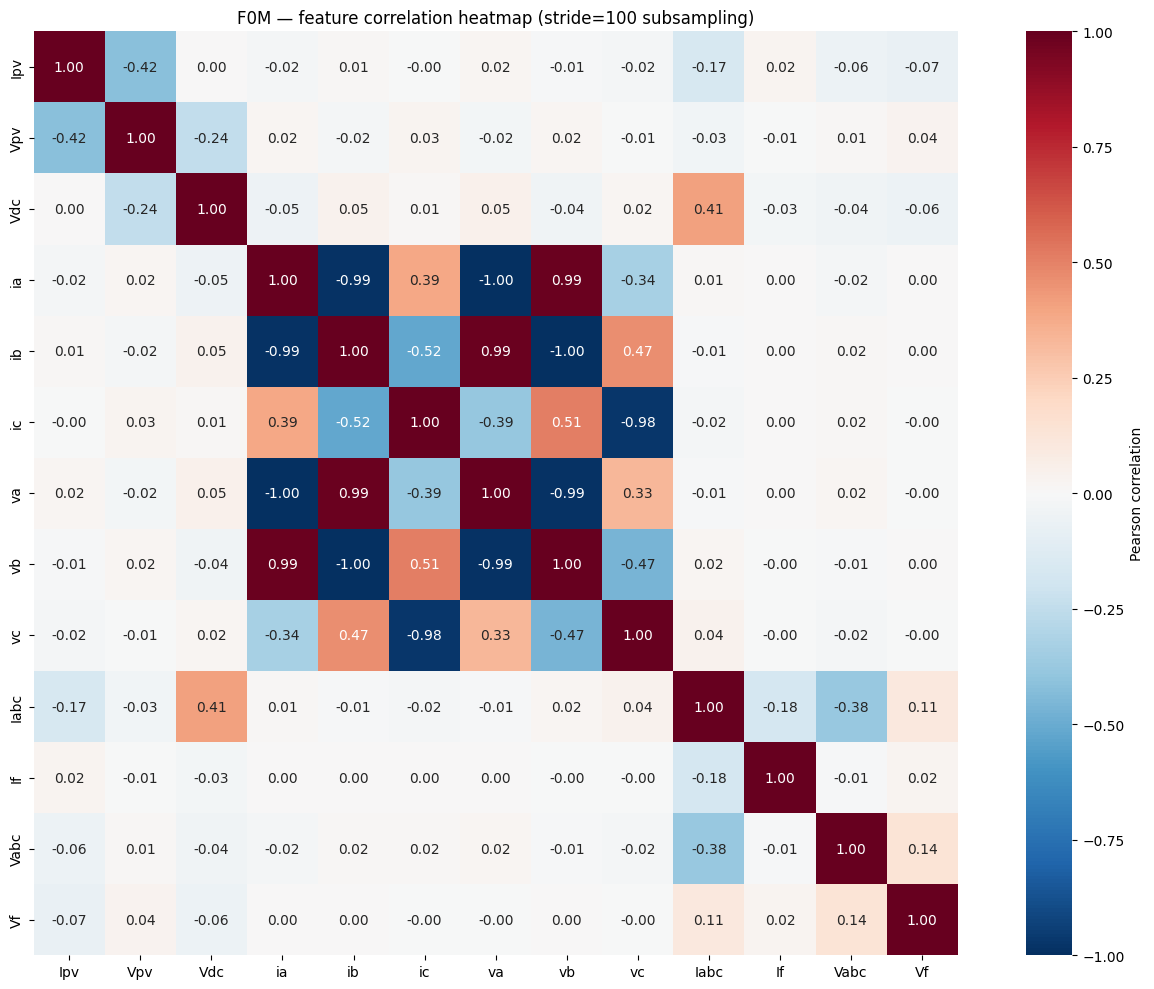

In [7]:
# Subsample before correlating — resolves the -1.00 artefacts that appear
# when computing Pearson correlation on densely sampled 50 Hz sinusoids
df0_sub = df0.iloc[::100].drop(columns=['Time'])
df0_corr = df0_sub.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(df0_corr, cmap='RdBu_r', annot=True, fmt='.2f',
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'label': 'Pearson correlation'})
plt.title('F0M — feature correlation heatmap (stride=100 subsampling)')
plt.tight_layout()
plt.show()

### Plot 4 — Rolling statistics for Vpv and Ipv

Rolling mean (window = 1000 samples ≈ 10 ms) and rolling standard deviation confirm that DC-side signals are stationary during MPPT operation. The Ipv rolling mean reveals a low-frequency oscillation characteristic of MPPT perturbation — a baseline behaviour that faults affecting the MPPT controller (F6M, F7M) are expected to disturb.

In [8]:
window = 1000
df0['Vpv_Rolling_Mean'] = df0['Vpv'].rolling(window=window).mean()
df0['Vpv_Rolling_Std']  = df0['Vpv'].rolling(window=window).std()
df0['Ipv_Rolling_Mean'] = df0['Ipv'].rolling(window=window).mean()
df0['Ipv_Rolling_Std']  = df0['Ipv'].rolling(window=window).std()

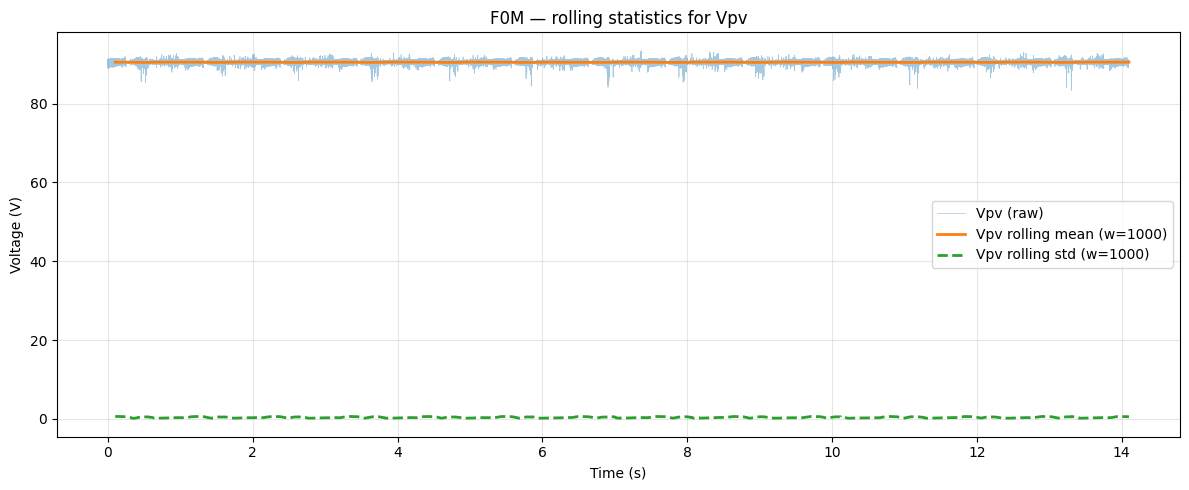

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df0['Time'], df0['Vpv'], label='Vpv (raw)', alpha=0.4, linewidth=0.5)
ax.plot(df0['Time'], df0['Vpv_Rolling_Mean'], label=f'Vpv rolling mean (w={window})', linewidth=2)
ax.plot(df0['Time'], df0['Vpv_Rolling_Std'],  label=f'Vpv rolling std (w={window})',  linewidth=2, linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')
ax.set_title('F0M — rolling statistics for Vpv')
ax.legend(loc='center right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

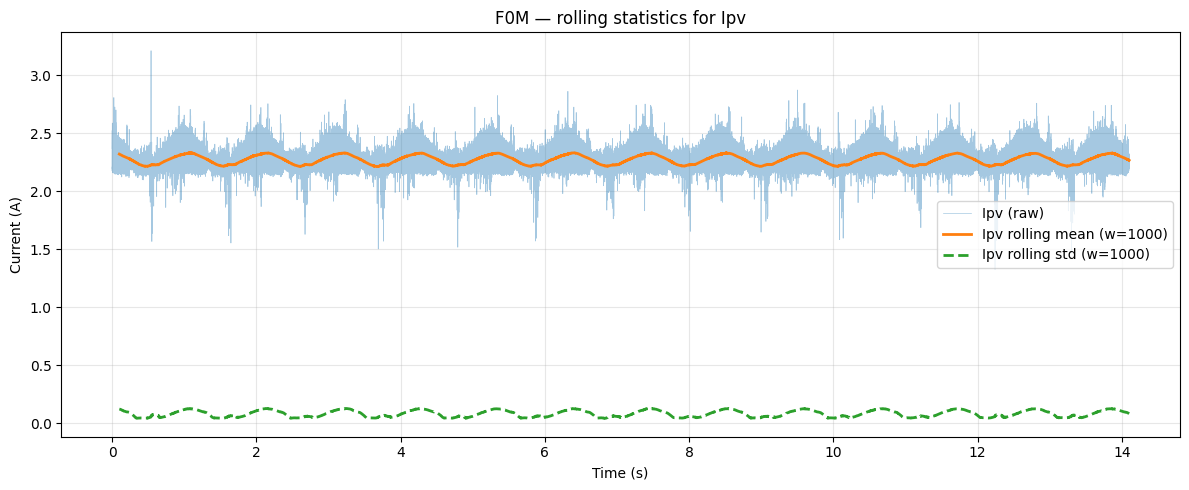

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df0['Time'], df0['Ipv'], label='Ipv (raw)', alpha=0.4, linewidth=0.5)
ax.plot(df0['Time'], df0['Ipv_Rolling_Mean'], label=f'Ipv rolling mean (w={window})', linewidth=2)
ax.plot(df0['Time'], df0['Ipv_Rolling_Std'],  label=f'Ipv rolling std (w={window})',  linewidth=2, linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Current (A)')
ax.set_title('F0M — rolling statistics for Ipv')
ax.legend(loc='center right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Reference Signal summary

F0M establishes the healthy operation baseline: DC side stationary at Vpv ≈ 90 V and Vdc ≈ 148 V, AC side stabilising within ~200 ms of startup to a balanced three-phase sinusoidal output at ~155 V peak, frequencies holding at 50 Hz. The correlation structure reflects the dominant physical relationships — the PV I–V characteristic (Ipv-Vpv) and the DC-link to AC-side power transfer (Vdc-Iabc). The Ipv rolling mean exposes the MPPT perturbation frequency, a baseline dynamic that fault classes targeting the MPPT controller are expected to disrupt.

With the reference signal established, fault data examines how each of the seven fault classes breaks this pattern.

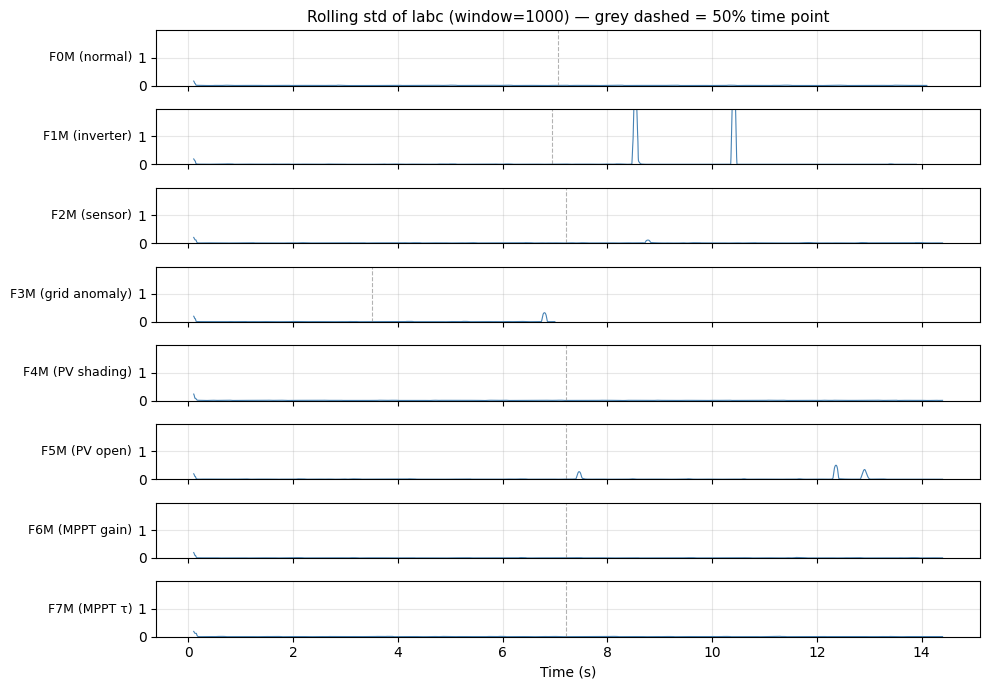

In [13]:
files = {
    'F0M (normal)': df0, 'F1M (inverter)': df1, 'F2M (sensor)':      df2, 'F3M (grid anomaly)':  df3,
    'F4M (PV shading)':  df4, 'F5M (PV open)':    df5, 'F6M (MPPT gain)': df6, 'F7M (MPPT τ)':        df7,
}

FEATURE = 'Iabc'
WINDOW  = 1000

# Compute rolling std per file, store for shared y-axis scaling
rolling_stds = {
    label: df0[FEATURE].rolling(window=WINDOW).std()
    for label, df0 in files.items()
}

# Global y-axis range — use 99th percentile to avoid extreme-outlier domination
y_max = max(r.quantile(0.99) for r in rolling_stds.values()) * 1.1
y_min = 0

fig, axes = plt.subplots(8, 1, figsize=(10, 7), sharex=True, sharey=True)

for ax, (label, df) in zip(axes, files.items()):
    t = df['Time']
    r = rolling_stds[label]
    ax.plot(t, r, linewidth=0.8, color='steelblue')

    # Mark the 'halfway through' point Bakdi et al. reference
    t_mid = t.iloc[len(t) // 2]
    ax.axvline(t_mid, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

    ax.set_ylabel(label, rotation=0, ha='right', va='center', fontsize=9)
    ax.set_ylim(y_min, y_max)
    ax.grid(alpha=0.3)

axes[0].set_title(f'Rolling std of {FEATURE} (window={WINDOW}) — grey dashed = 50% time point',
                  fontsize=11)
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()